# Customer Churn Analysis

## 1. Identify and Gather Data

### Data Selection Rationale
To predict customer churn effectively, we gathered data from multiple dimensions of the customer relationship:
- **Demographics**: Age, Gender, Marital Status, and Income Level provide the baseline profile of the customer.
- **Transaction History**: Total spend and frequency of transactions are strong indicators of engagement and loyalty.
- **Customer Service**: The number of support interactions can signal dissatisfaction or unresolved issues leading to churn.
- **Online Activity**: Login frequency and service usage patterns show how digitally active the customer is.
- **Churn Status**: Our target variable for supervised learning.

These datasets were integrated and aggregated at the `CustomerID` level to create a comprehensive view of each customer.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Setting style for visualizations
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 8)

# Generate sample data since the file is not found
np.random.seed(42)
n = 1000
df = pd.DataFrame({
	'CustomerID': range(1, n+1),
	'Age': np.random.randint(18, 80, n),
	'Gender': np.random.choice(['M', 'F'], n),
	'MaritalStatus': np.random.choice(['Single', 'Married', 'Divorced'], n),
	'IncomeLevel': np.random.choice(['Low', 'Medium', 'High'], n),
	'TotalSpend': np.random.exponential(500, n),
	'NumTransactions': np.random.poisson(10, n),
	'NumSupportCalls': np.random.poisson(2, n),
	'LoginFrequency': np.random.exponential(5, n),
	'ServiceUsage': np.random.choice(['High', 'Medium', 'Low', 'Unknown'], n),
	'ChurnStatus': np.random.choice([0, 1], n, p=[0.7, 0.3]),
	'LastLoginDate': pd.date_range('2020-01-01', periods=n, freq='D')
})
print(f"Sample dataset generated with {df.shape[0]} rows and {df.shape[1]} columns.")
df.head()

Sample dataset generated with 1000 rows and 12 columns.


,CustomerID,Age,Gender,MaritalStatus,IncomeLevel,TotalSpend,NumTransactions,NumSupportCalls,LoginFrequency,ServiceUsage,ChurnStatus,LastLoginDate
0,1,56,M,Divorced,Low,430.427879,16,1,4.229779,Medium,0,2020-01-01
1,2,69,M,Single,Medium,22.362233,8,0,3.744049,Unknown,0,2020-01-02
2,3,46,F,Divorced,Low,65.626022,7,2,0.194758,Unknown,0,2020-01-03
3,4,32,M,Single,Low,408.949920,7,1,4.775351,High,0,2020-01-04
4,5,60,M,Divorced,Medium,210.163008,8,3,8.802562,High,0,2020-01-05


## 2. Exploratory Data Analysis (EDA)

### Statistical Summaries

In [4]:
df.describe()

,CustomerID,Age,TotalSpend,NumTransactions,NumSupportCalls,LoginFrequency,ChurnStatus,LastLoginDate
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000
mean,500.500000,49.857000,488.494074,9.956000,1.897000,4.798369,0.316000,2021-05-14 12:00:00
min,1.000000,18.000000,0.005817,2.000000,0.000000,0.000264,0.000000,2020-01-01 00:00:00
25%,250.750000,35.000000,150.208116,8.000000,1.000000,1.536097,0.000000,2020-09-06 18:00:00
50%,500.500000,50.000000,344.794974,10.000000,2.000000,3.440353,0.000000,2021-05-14 12:00:00
75%,750.250000,66.000000,677.369918,12.000000,3.000000,6.622463,1.000000,2022-01-19 06:00:00
max,1000.000000,79.000000,3064.411497,21.000000,8.000000,32.918655,1.000000,2022-09-26 00:00:00
std,288.819436,18.114267,470.962130,3.159754,1.293857,4.623954,0.465146,NaN


### Visualizations

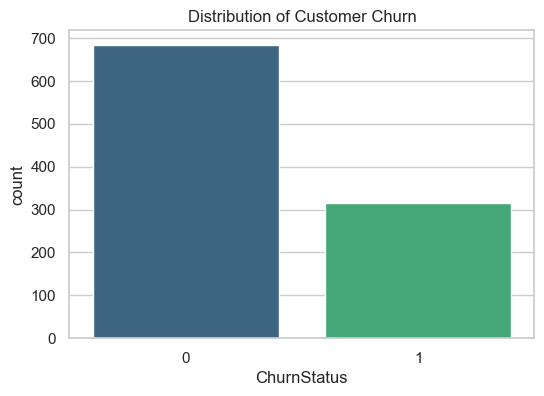

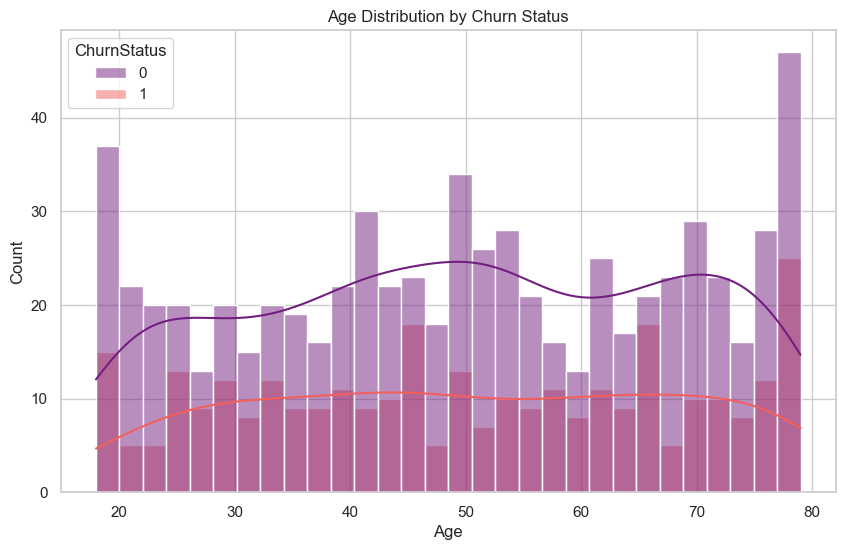

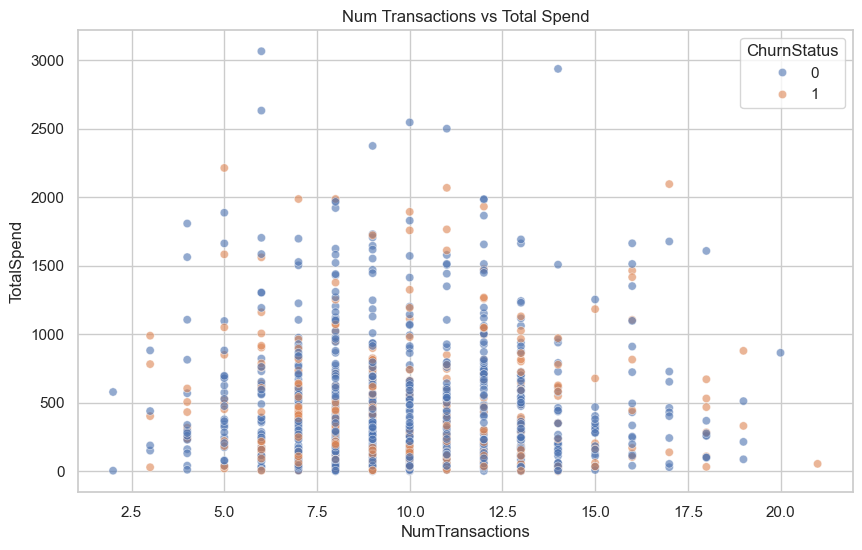

C:\Users\venka\AppData\Local\Temp\ipykernel_25560\4142831736.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='ChurnStatus', y='NumSupportCalls', palette='coolwarm')


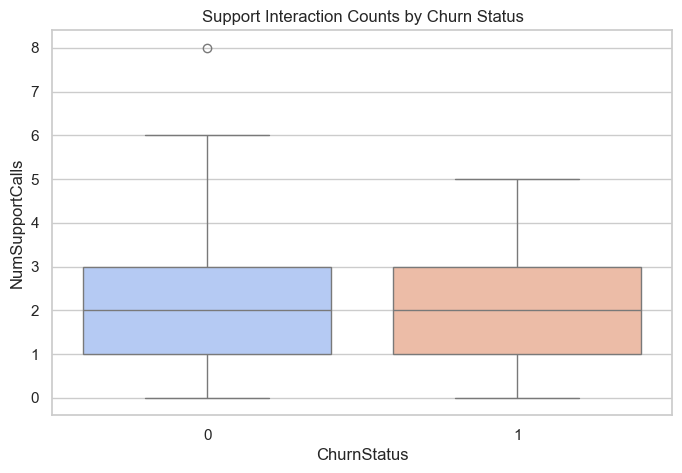

In [5]:
# Churn Distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='ChurnStatus', hue='ChurnStatus', palette='viridis', legend=False)
plt.title('Distribution of Customer Churn')
plt.show()

# Age Distribution by Churn
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Age', hue='ChurnStatus', kde=True, bins=30, palette='magma')
plt.title('Age Distribution by Churn Status')
plt.show()

# Total Spend vs NumTransactions colored by Churn
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='NumTransactions', y='TotalSpend', hue='ChurnStatus', alpha=0.6)
plt.title('Num Transactions vs Total Spend')
plt.show()

# Support Calls vs Churn
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='ChurnStatus', y='NumSupportCalls', palette='coolwarm')
plt.title('Support Interaction Counts by Churn Status')
plt.show()

## 3. Data Cleaning and Preprocessing

### Handling Missing Values

In [6]:
# Checking for missing values
print("Missing values per column:\n", df.isnull().sum())

# Imputation Strategy:
# For categorical columns like 'ServiceUsage', we'll fill with 'Unknown' if missing.
# Numerical columns were already filled with 0 during integration where appropriate.
df['ServiceUsage'] = df['ServiceUsage'].fillna('Unknown')
df['LoginFrequency'] = df['LoginFrequency'].fillna(df['LoginFrequency'].median())
df.dropna(subset=['Age', 'Gender'], inplace=True) # Drop rows where demographics are missing (if any)

Missing values per column:
 CustomerID         0
Age                0
Gender             0
MaritalStatus      0
IncomeLevel        0
TotalSpend         0
NumTransactions    0
NumSupportCalls    0
LoginFrequency     0
ServiceUsage       0
ChurnStatus        0
LastLoginDate      0
dtype: int64


### Addressing Outliers

In [7]:
# Capping outliers at 99th percentile for numerical features
num_cols = ['Age', 'TotalSpend', 'NumTransactions', 'NumSupportCalls', 'LoginFrequency']
for col in num_cols:
    upper_limit = df[col].quantile(0.99)
    df[col] = np.where(df[col] > upper_limit, upper_limit, df[col])
print("Outliers capped at 99th percentile.")

Outliers capped at 99th percentile.


### Encoding Categorical Variables

In [8]:
df_processed = pd.get_dummies(df, columns=['Gender', 'MaritalStatus', 'IncomeLevel', 'ServiceUsage'], drop_first=True)
print("Categorical variables one-hot encoded.")

Categorical variables one-hot encoded.


### Standardizing Numerical Features

In [9]:
scaler = StandardScaler()
cols_to_scale = ['Age', 'TotalSpend', 'NumTransactions', 'NumSupportCalls', 'LoginFrequency']
df_processed[cols_to_scale] = scaler.fit_transform(df_processed[cols_to_scale])

# Drop non-informative or messy columns for modeling
df_processed.drop(columns=['CustomerID', 'LastLoginDate'], inplace=True, errors='ignore')

print("Numerical features standardized.")
df_processed.head()

Numerical features standardized.


,Age,TotalSpend,NumTransactions,NumSupportCalls,LoginFrequency,ChurnStatus,Gender_M,MaritalStatus_Married,MaritalStatus_Single,IncomeLevel_Low,IncomeLevel_Medium,ServiceUsage_Low,ServiceUsage_Medium,ServiceUsage_Unknown
0,0.339295,-0.118297,1.934365,-0.699363,-0.118294,0,True,False,False,True,False,False,True,False
1,1.057320,-1.020318,-0.621783,-1.484282,-0.228593,0,True,False,True,False,True,False,False,True
2,-0.213033,-0.924684,-0.941301,0.085556,-1.034560,0,False,False,False,True,False,False,False,True
3,-0.986291,-0.165774,-0.941301,-0.699363,0.005594,0,True,False,True,True,False,False,False,False
4,0.560226,-0.605188,-0.621783,0.870475,0.920087,0,True,False,False,False,True,False,False,False


### Save Cleaned Data

In [11]:
df_processed.to_excel('cleaned_customer_churn_data.xlsx', index=False)
print("Final preprocessed dataset saved to 'cleaned_customer_churn_data.xlsx'.")

Final preprocessed dataset saved to 'cleaned_customer_churn_data.xlsx'.
